In [1]:
LOAD_ASSESSMENT = True
ASSESSMENT_PATH = "./_exports/other/df_trustworthiness.csv"

In [2]:
# load Basins with Data
from utils.export import BasinWithTrainingData
import pickle
dataset_names = ['Moon', 'S-Curve', 'Swiss Roll', 'Iris', 'Glass', 'Mushroom', 'Cardio']
basins = []
for dataset_name in dataset_names:
	dBasin:BasinWithTrainingData = pickle.load(open(f"_exports/other/dBasin_{dataset_name}.pkl", 'rb'))
	basins.append(dBasin)

In [3]:
# calculate trustworthiness across varying k neighborhood setting
import numpy as np
import pandas as pd
from utils.som_trustworthiness import calc_som_trustworthiness_umatrix, calc_som_trustworthiness_umatrix_altered

k_candidates = np.arange(5, 50+1, 5)

if LOAD_ASSESSMENT:
	df_trustworthiness = pd.read_csv(ASSESSMENT_PATH, index_col=[0, 1])
	df_trustworthiness.columns = df_trustworthiness.columns.astype(int)
else:
	df_trustworthiness = pd.DataFrame(
		columns=k_candidates,
		index=pd.MultiIndex.from_product([dataset_names, ["M_baseline", "M_altered"]], names=["dataset", "metric"])
	)

	for dataset_name, dBasin in zip(dataset_names, basins):
		for k in k_candidates:
			print(dataset_name, k)
			df_trustworthiness.loc[(dataset_name, "M_baseline"), k] = calc_som_trustworthiness_umatrix(dBasin.basin.som_representation.som, dBasin.X_train, k)
			df_trustworthiness.loc[(dataset_name, "M_altered"), k] = calc_som_trustworthiness_umatrix_altered(dBasin.basin.som_representation.som, dBasin.X_train, k)

	df_trustworthiness.to_csv(ASSESSMENT_PATH)

Moon 5
Moon 10
Moon 15
Moon 20
Moon 25
Moon 30
Moon 35
Moon 40
Moon 45
Moon 50
S-Curve 5
S-Curve 10
S-Curve 15
S-Curve 20
S-Curve 25
S-Curve 30
S-Curve 35
S-Curve 40
S-Curve 45
S-Curve 50
Swiss Roll 5
Swiss Roll 10
Swiss Roll 15
Swiss Roll 20
Swiss Roll 25
Swiss Roll 30
Swiss Roll 35
Swiss Roll 40
Swiss Roll 45
Swiss Roll 50
Iris 5
Iris 10
Iris 15
Iris 20
Iris 25
Iris 30
Iris 35
Iris 40
Iris 45
Iris 50
Glass 5
Glass 10
Glass 15
Glass 20
Glass 25
Glass 30
Glass 35
Glass 40
Glass 45
Glass 50
Mushroom 5
Mushroom 10
Mushroom 15
Mushroom 20
Mushroom 25
Mushroom 30
Mushroom 35
Mushroom 40
Mushroom 45
Mushroom 50
Cardio 5
Cardio 10
Cardio 15
Cardio 20
Cardio 25
Cardio 30
Cardio 35
Cardio 40
Cardio 45
Cardio 50


In [4]:
df_trustworthiness.style \
	.format(precision=4)

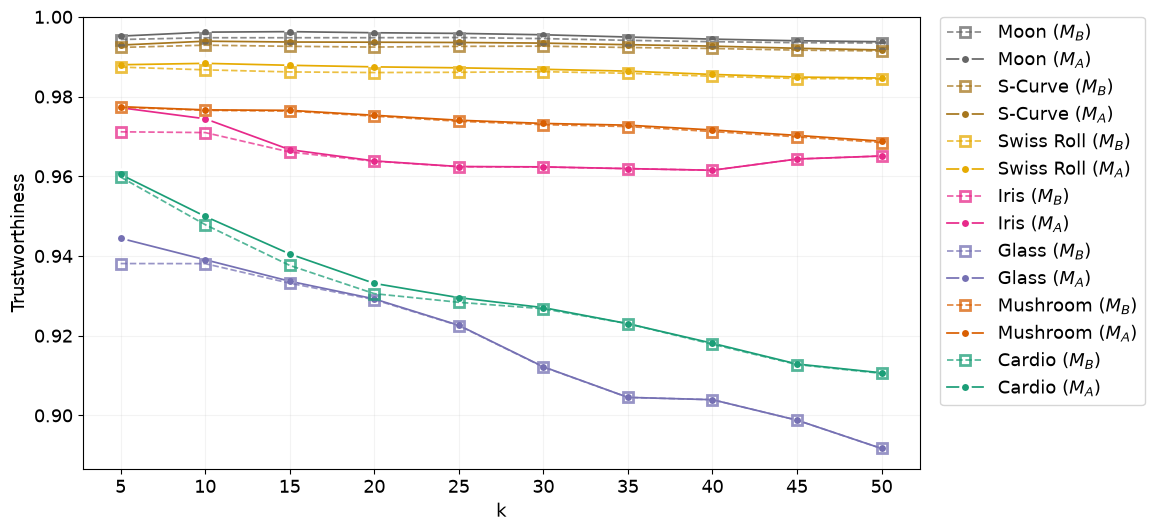

In [50]:
# plot trustworthiness chart
import matplotlib.pyplot as plt

plt.rc("font", size=13)

fig = plt.figure(figsize=(12, 5.5))
ax = plt.gca()

df_m_baseline = df_trustworthiness.xs("M_baseline", level='metric')
df_m_baseline.T.plot(kind='line', marker='s', markerfacecolor="none", markersize=7, markeredgewidth=2.0, linestyle="dashed", linewidth=1.25, cmap="Dark2_r", alpha=.75, zorder=3, ax=ax)

df_m_altered = df_trustworthiness.xs("M_altered", level='metric')
df_m_altered.T.plot(kind='line', marker='o', markersize=7, markeredgewidth=2.0, markeredgecolor="white", linestyle="solid", linewidth=1.25, cmap="Dark2_r", zorder=2, ax=ax)


ax.set_xlabel("k")
ax.set_ylabel("Trustworthiness")
plt.ylim(top=1.0)
plt.xticks(k_candidates)
plt.grid(alpha=.15)

handles, labels = ax.get_legend_handles_labels()
num_datasets = len(dataset_names)
handles_base = handles[:num_datasets]
handles_alt = handles[num_datasets:]
labels_base = labels[:num_datasets]
labels_alt = labels[num_datasets:]
new_handles = [h for pair in zip(handles_base, handles_alt) for h in pair]
new_labels = [l for pair in zip(list(map(lambda _: f"{_} ($M_B$)",labels_base)), list(map(lambda _: f"{_} ($M_A$)", labels_alt))) for l in pair]
plt.legend(handles=new_handles, labels=new_labels, loc="upper right", bbox_to_anchor=(1.28, 1.02))
plt.tight_layout()
plt.show()

plt.rc("font", size=10)

In [51]:
# export fig
def export_figure(fig, dir_path, file_name, hide_titles=True):
    import os
    if hide_titles:
        fig.suptitle('')
        for ax in fig.axes:
            ax.set_title('')

    save_path = os.path.join(dir_path, file_name)
    fig.savefig(save_path, bbox_inches='tight')

    print(f"Figure saved to `_exports` folder as `{file_name}`")

export_figure(fig, "_exports", "05_trustworthiness_chart.png")

Figure saved to `_exports` folder as `05_trustworthiness_chart.png`


---

In [15]:
from utils.som_knn import get_minimal_path_knn_inds, get_minimal_path_altered_knn_inds

def get_knn_projections(som, X_train, x_idx, k):
	som_weights = som.get_weights()
	som_shape = som_weights.shape[:2]
	som_winmap = som.win_map(X_train, return_indices=True)
	som_distmap = som.distance_map(scaling="mean")

	x = X_train[x_idx]

	knn_projection_inds = get_minimal_path_knn_inds(som, som_weights, som_winmap, som_distmap, som_shape, X_train, x, x_idx, k)
	knn_projection_altered_inds = get_minimal_path_altered_knn_inds(som, som_weights, som_winmap, som_distmap, som_shape, X_train, x, x_idx, k)

	return knn_projection_inds, knn_projection_altered_inds

In [28]:
selected_datasets = ["Iris"]
selected_datasets_inds = list(map(lambda d: np.argwhere(np.array(dataset_names) == d)[0][0], selected_datasets))
selected_basins = np.array(basins)[selected_datasets_inds]
selected_sample_inds = [43, 103]

In [44]:
for dBasin, dataset_name, x_idx in zip(selected_basins, selected_datasets, selected_sample_inds):
	x = dBasin.X_train[x_idx]
	knn_projection_inds, knn_projection_altered_inds = get_knn_projections(dBasin.basin.som_representation.som, dBasin.X_train, x_idx, k=10)

	d1, d2 = dBasin.basin.som_representation.lattice_shape_
	from utils.plotting import PlotlyHelperArgs
	plot_args = dict(
		**PlotlyHelperArgs.Figsize(w=400, h=250),
		**PlotlyHelperArgs.FullStretch,
		**PlotlyHelperArgs.HiddenTicks(d1=d1, d2=d2),
		font=dict(size=35),
		showlegend=False
	)

	fig1 = dBasin.basin.pond() \
		.pad_layer(gap="nogap") \
		.rhizome_layer() \
    	.petal_layer() \
		.visualize(**plot_args);

	fig2 = dBasin.basin.pond() \
		.pad_layer(gap="nogap") \
		.attraction_layer(X=dBasin.X_train[knn_projection_inds], jitter_amount=.3, marker=dict(color="crimson", symbol="star-diamond", size=20, opacity=.9)) \
		.attraction_layer(X=dBasin.X_train[[x_idx]], marker=dict(color="gold", symbol="star", size=20, opacity=.95)) \
		.visualize(**plot_args);

	fig3 = dBasin.basin.pond() \
		.pad_layer(gap="nogap") \
    	.rhizome_layer(X=[x], max_width=10) \
		.attraction_layer(X=dBasin.X_train[knn_projection_altered_inds], jitter_amount=.3, marker=dict(color="crimson", symbol="star-diamond", size=20, opacity=.9)) \
		.attraction_layer(X=dBasin.X_train[[x_idx]], marker=dict(color="gold", symbol="star", size=20, opacity=.95)) \
		.visualize(**plot_args);

	EXPORT_DIR = "_exports"
	fig1.write_image(EXPORT_DIR + f"/05_{dataset_name}_lilypond_01.png")
	fig2.write_image(EXPORT_DIR + f"/05_{dataset_name}_lilypond_02.png")
	fig3.write_image(EXPORT_DIR + f"/05_{dataset_name}_lilypond_03.png")